### Exercise 11.5: Load and Explore the Air Passengers Time Series

* Use `statsmodels.datasets.get_rdataset('AirPassengers').data` to load the classic monthly airline passenger dataset.
* Convert the `'time'` column to a pandas DatetimeIndex and set it as the DataFrame index.
* Rename the passenger count column to `Passengers`.
* Print the first 5 rows and summary statistics for `Passengers`.
* Plot the full time series of monthly airline passengers.

In [4]:
pip install scikit-learn pandas numpy matplotlib statsmodels


  Using cached scikit_learn-1.7.2-cp312-cp312-macosx_12_0_arm64.whl.metadata (11 kB)
  Using cached pandas-2.3.3-cp312-cp312-macosx_11_0_arm64.whl.metadata (91 kB)
  Using cached numpy-2.3.3-cp312-cp312-macosx_14_0_arm64.whl.metadata (62 kB)
  Using cached matplotlib-3.10.7-cp312-cp312-macosx_11_0_arm64.whl.metadata (11 kB)
  Using cached statsmodels-0.14.5-cp312-cp312-macosx_11_0_arm64.whl.metadata (9.5 kB)
  Using cached scipy-1.16.2-cp312-cp312-macosx_14_0_arm64.whl.metadata (62 kB)
  Using cached joblib-1.5.2-py3-none-any.whl.metadata (5.6 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
  Using cached pytz-2025.2-py2.py3-none-any.whl.metadata (22 kB)
  Using cached tzdata-2025.2-py2.py3-none-any.whl.metadata (1.4 kB)
  Using cached contourpy-1.3.3-cp312-cp312-macosx_11_0_arm64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.60.1-cp312-cp312-macosx_10_13_universal2.whl.metadata (112 kB)
  Using

                   time  Passengers
Date                               
1949-01-01  1949.000000         112
1949-01-01  1949.083333         118
1949-03-01  1949.166667         132
1949-04-01  1949.250000         129
1949-04-01  1949.333333         121
              time  Passengers
count   144.000000  144.000000
mean   1954.958333  280.298611
std       3.476109  119.966317
min    1949.000000  104.000000
25%    1951.979167  180.000000
50%    1954.958333  265.500000
75%    1957.937500  360.500000
max    1960.916667  622.000000


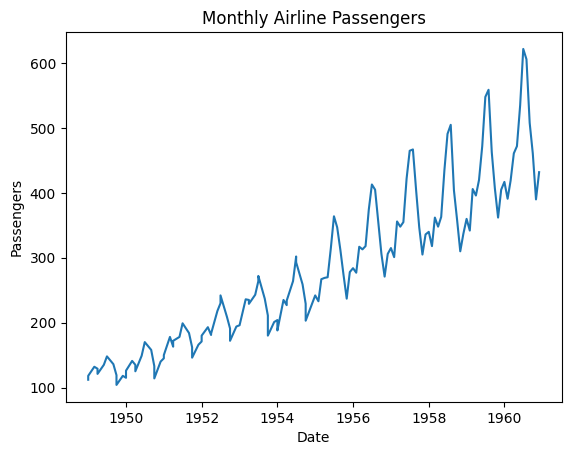

In [ ]:
import statsmodels.api as sm
import pandas as pd
import matplotlib.pyplot as plt

#Data handling

data = sm.datasets.get_rdataset('AirPassengers').data
data['Date'] = pd.to_datetime({'year': data['time'].astype(int), 'month': ((data['time'] % 1)*12+1).astype(int), 'day': 1})
data.set_index('Date', inplace=True)
data.rename(columns={'value': 'Passengers'}, inplace=True)

#Output
print(data.head(5))
summary= data.describe() 
print(summary)

#Plotting time series 
plt.Figure(figsize=(5,5))
plt.plot(data.index, data["Passengers"])
plt.title('Monthly Airline Passengers')
plt.xlabel('Date')
plt.ylabel('Passengers')
plt.show()

#### Solution

```python

                   time  Passengers
Date                               
1949-01-01  1949.000000         112
1949-01-01  1949.083333         118
1949-03-01  1949.166667         132
1949-04-01  1949.250000         129
1949-04-01  1949.333333         121
count    144.000000
mean     280.298611
std      119.966317
min      104.000000
25%      180.000000
50%      265.500000
75%      360.500000
max      622.000000
Name: Passengers, dtype: float64


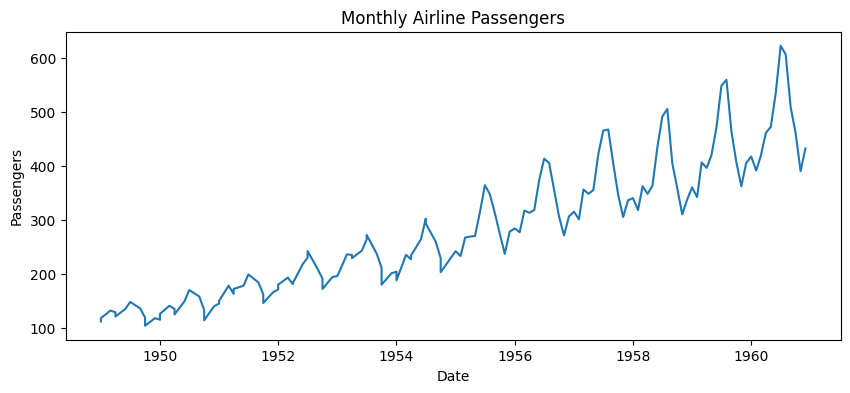

In [6]:
import statsmodels.api as sm
import pandas as pd
import matplotlib.pyplot as plt

data = sm.datasets.get_rdataset('AirPassengers').data
data['Date'] = pd.to_datetime({'year': data['time'].astype(int), 'month': ((data['time'] % 1)*12+1).astype(int), 'day': 1})
data.set_index('Date', inplace=True)
data.rename(columns={'value': 'Passengers'}, inplace=True)

print(data.head())
print(data['Passengers'].describe())

plt.figure(figsize=(10,4))
plt.plot(data.index, data['Passengers'])
plt.title('Monthly Airline Passengers')
plt.xlabel('Date')
plt.ylabel('Passengers')
plt.show()

### Exercise 11.6: Simple Hold-Out Validation for Time Series

* Using the DataFrame from 11.5, create a new column called `TimeIndex` that counts months since the first observation (0, 1, 2, ...).
* Use the first 80% of the data (in time order) as the training set and the remaining 20% as the test set.
* Fit a linear regression model to predict `Passengers` using `TimeIndex` as the only predictor.
* Predict on the test set and compute the RMSE.
* Print the RMSE on the test set.

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
import numpy as np 

# Data manipulation
df_11_6=data.copy()

df_11_6["TimeIndex"]=range(len(df_11_6)) 

# Assume `df` is your DataFrame and 'target' is the column to predict
X =df_11_6.drop("Passengers", axis=1)
y = df_11_6['Passengers']

# Simple Train/Test Split (80% / 20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,  # sets seed for reproducibility
    shuffle=False      # set to False for time series data
)

# Setting up linear regression 
reg=LinearRegression()

reg.fit(X_train,y_train) #Training set (fit) → learn relationships.

y_predicted = reg.predict(X_test) #Test set (predict) → check if the learned relationships generalize to unseen data.


# Metrics for evaluation 
MAE = np.mean(np.abs(y_test- y_predicted))
MSE = np.mean((y_test - y_predicted)**2)
RMSE = np.sqrt(MSE)
MAPE = np.mean(np.abs((y_test-y_predicted) / y)) *100


print(f"MAE: {MAE:.6f}\nRMSE: {RMSE:.6f}\nMSE: {MSE:.6f}\nMAPE {MAPE:.6f} ")





MAE: 55.969828
RMSE: 73.943066
MSE: 5467.577047
MAPE 12.067612 


#### Solution



In [32]:
data['TimeIndex'] = range(len(data))
split_idx = int(0.8 * len(data))
train = data.iloc[:split_idx]
test = data.iloc[split_idx:]

from sklearn.linear_model import LinearRegression
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_absolute_error, r2_score, mean_squared_error

X_train = train[['TimeIndex']]
y_train = train['Passengers']
X_test = test[['TimeIndex']]
y_test = test['Passengers']

lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print("Test set RMSE:", rmse)

Test set RMSE: 73.8049023621349


### Exercise 11.7: Compare Rolling and Expanding Window Cross-Validation

* Using the DataFrame and `TimeIndex` feature from 11.6, evaluate linear regression using both:
    1. Rolling window cross-validation (fixed-size training window)
    2. Expanding window cross-validation (training window grows each split)
* For both methods, use 5 validation splits:
    - For rolling window: use the most recent 60 observations as the training set for each split.
    - For expanding window: use all available data up to each validation split as the training set. (so max_train_size = None (default))
    - For both, use the next 24 observations as the validation set.
* For each split, fit a linear regression model on the training data (`TimeIndex` as predictor) and predict on the validation set.
* Compute and print the RMSE for each fold, for both methods.
* Print the mean and standard deviation of RMSE across all folds, for both methods.
* Compare and comment on which approach provides more stable performance.


In [9]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, root_mean_squared_error
import numpy as np


df_11_7=df_11_6.copy()


#=======================#
#    Expanding window
#=======================#

# Setting X and y 
X= df_11_7[["TimeIndex"]].values #X is a 2D NumPy array. dobbelt brackets and . values makes it into a numpy series
y= df_11_7["Passengers"].values #.vvalue makes y into a 1D NumPy array 

# Setting the crossvalidtaion and reg
exp_w_cv= TimeSeriesSplit(n_splits=5,test_size=24,max_train_size=None) #n_splits# is how many folds to make, the #test_size# is the size of the validation/ test set. #gap# is how many values to exclude inbetween the training and test/validation set in each fold. #max_train_size# is how large the traning set is, it is used when not all data should be used in the expandning window, so it exlucdes some of the older data. 

print("Expanding window results:\n")

rmse_1=[]
for train_idx, test_idx in (exp_w_cv.split(X)):
    X_train , X_test = X[train_idx], X[test_idx]
    y_train , y_test = y[train_idx],y[test_idx]
    reg=LinearRegression()
    reg.fit(X_train,y_train)
    y_predicted=reg.predict(X_test)
    rmse=root_mean_squared_error(y_test,y_predicted)
    rmse_1.append(rmse)
    print(rmse)

print(f"RMSE mean: {np.mean(rmse_1):.5f}\nRMSE std: {np.std(rmse_1):.5f}")

#=======================#
#    Rowling window
#=======================#
# Setting X and y 
X= df_11_7[["TimeIndex"]].values #X is a 2D NumPy array. dobbelt brackets and . values makes it into a numpy series
y= df_11_7["Passengers"].values #.vvalue makes y into a 1D NumPy array 

# Setting the crossvalidtaion and reg
exp_w_cv= TimeSeriesSplit(n_splits=5,test_size=24,max_train_size=60) #n_splits# is how many folds to make, the #test_size# is the size of the validation/ test set. #gap# is how many values to exclude inbetween the training and test/validation set in each fold. #max_train_size# is how large the traning set is, it is used when not all data should be used in the expandning window, so it exlucdes some of the older data. 
# max_train size= 60 makes it a roolling window! 


print("\nRolling window results:\n")

rmse_1=[]
for train_idx, test_idx in (exp_w_cv.split(X)):
    X_train , X_test = X[train_idx], X[test_idx]
    y_train , y_test = y[train_idx],y[test_idx]
    reg=LinearRegression()
    reg.fit(X_train,y_train)
    y_predicted=reg.predict(X_test)
    rmse=root_mean_squared_error(y_test,y_predicted)
    rmse_1.append(rmse)
    print(rmse)

print(f"RMSE mean: {np.mean(rmse_1):.5f}\nRMSE std: {np.std(rmse_1):.5f}")


Expanding window results:

34.21275088877599
30.948717969254183
51.66779299564629
62.13560330521181
74.787758856445
RMSE mean: 50.75052
RMSE std: 16.57625

Rolling window results:

34.21275088877599
30.948717969254183
49.81532339652174
59.43879295465249
69.4232395123053
RMSE mean: 48.76776
RMSE std: 14.63546


#### Comparison of Rolling and Expanding Window Cross-Validation

| Method | Mean RMSE | Std. RMSE |
|---------|------------|-----------|
| **Expanding window** | 50.75 | 16.58 |
| **Rolling window** | 48.77 | 14.64 |

---

**Interpretation**

*Expanding window*
- The training set grows over time, using all available past data for each split.  
- Older observations may reduce accuracy if the time series structure changes.  
- Slightly higher RMSE and higher variability indicate less stable performance.  

*Rolling window*
- Uses a fixed-size training set (the most recent 60 observations).  
- Focuses on recent patterns, adapting better to evolving trends.  
- Slightly lower RMSE and lower variability suggest more consistent performance.  

---

**Conclusion**
- Both methods perform similarly, but **rolling window cross-validation** gives **more stable and slightly more accurate** results.  
- This suggests that **recent data are more informative** for forecasting than older observations.  
- Use the rolling window approach when the data show **changing trends or evolving behavior** over time.


#### Solution



In [56]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import numpy as np

X = data[['TimeIndex']].values
y = data['Passengers'].values

# Expanding Window CV
exp_cv = TimeSeriesSplit(n_splits=5, test_size=24, max_train_size=None)
rmse_expanding = []
for i, (train_idx, test_idx) in enumerate(exp_cv.split(X)):
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]
    lr = LinearRegression()
    lr.fit(X_train, y_train)
    y_pred = lr.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    rmse_expanding.append(rmse)
    print(f"Expanding window fold {i+1} RMSE: {rmse:.2f}")

print("Expanding window mean RMSE: %.2f, std: %.2f" % (np.mean(rmse_expanding), np.std(rmse_expanding)))
print()

# Rolling Window CV
W, h = 60, 24  # Training window = 60, test window = 24
roll_cv = TimeSeriesSplit(n_splits=5, test_size=h, max_train_size=W)
rmse_rolling = []
for i, (train_idx, test_idx) in enumerate(roll_cv.split(X)):
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]
    lr = LinearRegression()
    lr.fit(X_train, y_train)
    y_pred = lr.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    rmse_rolling.append(rmse)
    print(f"Rolling window fold {i+1} RMSE: {rmse:.2f}")

print("Rolling window mean RMSE: %.2f, std: %.2f" % (np.mean(rmse_rolling), np.std(rmse_rolling)))


Expanding window fold 1 RMSE: 34.21
Expanding window fold 2 RMSE: 30.95
Expanding window fold 3 RMSE: 51.67
Expanding window fold 4 RMSE: 62.14
Expanding window fold 5 RMSE: 74.79
Expanding window mean RMSE: 50.75, std: 16.58

Rolling window fold 1 RMSE: 34.21
Rolling window fold 2 RMSE: 30.95
Rolling window fold 3 RMSE: 49.82
Rolling window fold 4 RMSE: 59.44
Rolling window fold 5 RMSE: 69.42
Rolling window mean RMSE: 48.77, std: 14.64


### Exercise 11.8: Lagged Features and Cross-Validation

* Add a new column to the DataFrame called `Lag1`, which is the passenger count in the previous month.
* Drop the first row to remove the missing lagged value.
* Use `TimeSeriesSplit` (5 splits) to fit a linear regression model using both `TimeIndex` and `Lag1` as predictors for `Passengers`.
* Compute and print the RMSE for each fold, and print the average RMSE.

In [ ]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, root_mean_squared_error
import numpy as np

# Data handling 
df_11_8=df_11_7.copy()

df_11_8["Lag1"] = df_11_8["Passengers"].shift(1)
df_11_8.drop("1949-01-01", inplace=True) # or just .dropna()


# Setting X and y 
X= df_11_8[["TimeIndex", "Lag1"]].values #X is a 2D NumPy array. dobbelt brackets and . values makes it into a numpy series
y= df_11_8["Passengers"].values #.vvalue makes y into a 1D NumPy array 

# Setting the crossvalidtaion
cv= TimeSeriesSplit(n_splits=5) #n_splits# is how many folds to make, the #test_size# is the size of the validation/ test set. #gap# is how many values to exclude inbetween the training and test/validation set in each fold. #max_train_size# is how large the traning set is, it is used when not all data should be used in the expandning window, so it exlucdes some of the older data. 
# max_train size= 60 makes it a roolling window! 


print("Results:\n")

rmse_1=[]
for i,(train_idx, test_idx) in enumerate(cv.split(X)):
    X_train , X_test = X[train_idx], X[test_idx]
    y_train , y_test = y[train_idx],y[test_idx]
    reg=LinearRegression()
    reg.fit(X_train,y_train)
    y_predicted=reg.predict(X_test)
    rmse=root_mean_squared_error(y_test,y_predicted)
    rmse_1.append(rmse)
    print(f"Fold {i+1} RMSE: {rmse:.5f}")

print(f"RMSE mean: {np.mean(rmse_1):.5f}\nRMSE std: {np.std(rmse_1):.5f}")




Results:

Fold 1 RMSE: 18.00885
Fold 2 RMSE: 22.69819
Fold 3 RMSE: 31.96541
Fold 4 RMSE: 42.23690
Fold 5 RMSE: 49.50766
RMSE mean: 32.88340
RMSE std: 11.74468


/var/folders/62/2zl_g_593t142qtwbk33680r0000gn/T/ipykernel_74273/3789065893.py:10: FutureWarning: The behavior of 'isin' with dtype=datetime64[ns] and castable values (e.g. strings) is deprecated. In a future version, these will not be considered matching by isin. Explicitly cast to the appropriate dtype before calling isin instead.
  df_11_8.drop("1949-01-01", inplace=True) # or just .dropna()


#### Solution




In [33]:
data['Lag1'] = data['Passengers'].shift(1)
data2 = data.dropna()
X = data2[['TimeIndex', 'Lag1']]
y = data2['Passengers']

tscv = TimeSeriesSplit(n_splits=5)
rmses = []
for train_idx, test_idx in tscv.split(X):
    X_tr, X_te = X.iloc[train_idx], X.iloc[test_idx]
    y_tr, y_te = y.iloc[train_idx], y.iloc[test_idx]
    lr = LinearRegression()
    lr.fit(X_tr, y_tr)
    y_pred = lr.predict(X_te)
    rmse = np.sqrt(mean_squared_error(y_te, y_pred))
    rmses.append(rmse)
    print("Fold RMSE:", rmse)
print("Average RMSE: %.4f" % np.mean(rmses))

Fold RMSE: 18.17180974518617
Fold RMSE: 22.656448838717004
Fold RMSE: 32.013802940662636
Fold RMSE: 42.260289699967906
Fold RMSE: 49.53430725518312
Average RMSE: 32.9273


### Exercise 11.9: Challenge — Model Selection with Time Series Cross-Validation

* Using the lagged feature from 11.8, compare three models using `TimeSeriesSplit` (5 splits):
    1. Linear regression with `TimeIndex` as the only predictor
    2. Linear regression with both `TimeIndex` and `Lag1` as predictors
    3. Polynomial regression of degree 2 using `TimeIndex` and `Lag1` (apply `PolynomialFeatures` and then linear regression)
* For each model, compute and print the average RMSE across all splits.
* Print the average RMSE for each model.

In [44]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error, root_mean_squared_error
from sklearn.pipeline import make_pipeline
import numpy as np

# Data
df_11_9=df_11_8.copy()

# Splitting the data with cv
cv=TimeSeriesSplit(n_splits=5)


#===================================#
# Setting the X's for each regression
#===================================#

# Regression 1
X_reg_1 = df_11_9[["TimeIndex"]].values
y_reg_1 = df_11_9["Passengers"].values

# Regression 2
X_reg_2= df_11_9[["TimeIndex", "Lag1"]].values #X is a 2D NumPy array. dobbelt brackets and . values makes it into a numpy series
y_reg_2= df_11_9["Passengers"].values 

# Regression 3
X_reg_3= df_11_9[["TimeIndex", "Lag1"]].values #X is a 2D NumPy array. dobbelt brackets and . values makes it into a numpy series
y_reg_3= df_11_9["Passengers"].values

#===================================#
# Regression 1 
#===================================#
print("Regression 1:")
rmse_1=[]
for i,(train_idx, test_idx) in enumerate(cv.split(X_reg_1)):
    X_train , X_test = X_reg_1[train_idx], X_reg_1[test_idx]
    y_train , y_test = y_reg_1[train_idx],y_reg_1[test_idx]
    reg=LinearRegression()
    reg.fit(X_train,y_train)
    y_predicted=reg.predict(X_test)
    rmse=root_mean_squared_error(y_test,y_predicted)
    rmse_1.append(rmse)
    print(f"Fold {i+1} RMSE: {rmse:.5f}")

print(f"RMSE mean: {np.mean(rmse_1):.5f}\nRMSE std: {np.std(rmse_1):.5f}")


#===================================#
# Regression 2
#===================================#
print("\nRegression 2:")
rmse_2=[]
for i,(train_idx, test_idx) in enumerate(cv.split(X_reg_2)):
    X_train , X_test = X_reg_2[train_idx], X_reg_2[test_idx]
    y_train , y_test = y_reg_2[train_idx],y_reg_2[test_idx]
    reg=LinearRegression()
    reg.fit(X_train,y_train)
    y_predicted=reg.predict(X_test)
    rmse=root_mean_squared_error(y_test,y_predicted)
    rmse_2.append(rmse)
    print(f"Fold {i+1} RMSE: {rmse:.5f}")

print(f"RMSE mean: {np.mean(rmse_2):.5f}\nRMSE std: {np.std(rmse_2):.5f}")


#===================================#
# Regression 3
#===================================#
print("\nRegression 3:")

poly2 = make_pipeline(PolynomialFeatures(2), LinearRegression())
rmse_3=[]
for i,(train_idx, test_idx) in enumerate(cv.split(X_reg_3)):
    X_train , X_test = X_reg_3[train_idx], X_reg_3[test_idx]
    y_train , y_test = y_reg_3[train_idx],y_reg_3[test_idx]
    reg=poly2
    reg.fit(X_train,y_train)
    y_predicted=reg.predict(X_test)
    rmse=root_mean_squared_error(y_test,y_predicted)
    rmse_3.append(rmse)
    print(f"Fold {i+1} RMSE: {rmse:.5f}")

print(f"RMSE mean: {np.mean(rmse_3):.5f}\nRMSE std: {np.std(rmse_3):.5f}")





Regression 1:
Fold 1 RMSE: 29.32863
Fold 2 RMSE: 31.22897
Fold 3 RMSE: 53.57711
Fold 4 RMSE: 63.78970
Fold 5 RMSE: 76.27883
RMSE mean: 50.84065
RMSE std: 18.27376

Regression 2:
Fold 1 RMSE: 18.00885
Fold 2 RMSE: 22.69819
Fold 3 RMSE: 31.96541
Fold 4 RMSE: 42.23690
Fold 5 RMSE: 49.50766
RMSE mean: 32.88340
RMSE std: 11.74468

Regression 3:
Fold 1 RMSE: 34.89725
Fold 2 RMSE: 28.73116
Fold 3 RMSE: 32.33892
Fold 4 RMSE: 42.78130
Fold 5 RMSE: 49.15483
RMSE mean: 37.58069
RMSE std: 7.40268


#### Solution



In [128]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

# Model 1: Linear with TimeIndex
tscv = TimeSeriesSplit(n_splits=5)
X = data2[['TimeIndex']]
y = data2['Passengers']
rmses_1 = []
for train_idx, test_idx in tscv.split(X):
    X_tr, X_te = X.iloc[train_idx], X.iloc[test_idx]
    y_tr, y_te = y.iloc[train_idx], y.iloc[test_idx]
    lr = LinearRegression()
    lr.fit(X_tr, y_tr)
    y_pred = lr.predict(X_te)
    rmses_1.append(np.sqrt(mean_squared_error(y_te, y_pred)))
print("Linear (TimeIndex only) average RMSE: %.4f" % np.mean(rmses_1))

# Model 2: Linear with TimeIndex and Lag1
X2 = data2[['TimeIndex', 'Lag1']]
rmses_2 = []
for train_idx, test_idx in tscv.split(X2):
    X_tr, X_te = X2.iloc[train_idx], X2.iloc[test_idx]
    y_tr, y_te = y.iloc[train_idx], y.iloc[test_idx]
    lr = LinearRegression()
    lr.fit(X_tr, y_tr)
    y_pred = lr.predict(X_te)
    rmses_2.append(np.sqrt(mean_squared_error(y_te, y_pred)))
print("Linear (TimeIndex + Lag1) average RMSE: %.4f" % np.mean(rmses_2))

# Model 3: Polynomial regression of degree 2 with TimeIndex and Lag1
poly2 = make_pipeline(PolynomialFeatures(2), LinearRegression())
rmses_3 = []
for train_idx, test_idx in tscv.split(X2):
    X_tr, X_te = X2.iloc[train_idx], X2.iloc[test_idx]
    y_tr, y_te = y.iloc[train_idx], y.iloc[test_idx]
    poly2.fit(X_tr, y_tr)
    y_pred = poly2.predict(X_te)
    rmses_3.append(np.sqrt(mean_squared_error(y_te, y_pred)))
print("Polynomial (deg 2, TimeIndex + Lag1) average RMSE: %.4f" % np.mean(rmses_3))

Linear (TimeIndex only) average RMSE: 50.8404
Linear (TimeIndex + Lag1) average RMSE: 32.9273
Polynomial (deg 2, TimeIndex + Lag1) average RMSE: 36.9084


### Exercise 11.10: Leave-One-Out Cross-Validation (LOOCV) on California Housing

* Load the California housing dataset as in 11.1.
* Select only the first 100 observations from the dataset for this exercise.
* Use scikit-learn’s `LeaveOneOut` cross-validator with linear regression to predict `MedHouseVal` from all features.
* Compute and print the mean RMSE across all LOOCV folds.

In [53]:
df_11_10

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422
...,...,...,...,...,...,...,...,...,...
95,2.0096,36.0,2.294016,1.066294,3469.0,1.493328,37.80,-122.26,1.300
96,2.8345,31.0,3.894915,1.127966,2048.0,1.735593,37.82,-122.26,1.838
97,2.0062,29.0,3.681319,1.175824,202.0,2.219780,37.81,-122.26,1.250
98,1.2185,22.0,2.945600,1.016000,2024.0,1.619200,37.82,-122.26,1.700


In [ ]:
from sklearn.datasets import fetch_california_housing
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import LeaveOneOut, cross_val_score
from sklearn.linear_model import LinearRegression

#Data handling
data = fetch_california_housing(as_frame=True) # as_frame=True makes the data into a dataframe
df_11_10 = data.frame

df_11_10 = df_11_10.head(100)  # inplace= true is default for head. 

#Features 
regression_feature=df_11_10[["MedInc", "HouseAge", "AveRooms","AveBedrms","Population", "AveOccup"	,"Latitude","Longitude"]]
y_11_10=df_11_10["MedHouseVal"]

#Setting up LOOCV and linear regression
LOOCV=LeaveOneOut() # takes no arguments 
reg=LinearRegression()


#regression 1
rmse_lr = -cross_val_score(reg,regression_feature,y_11_10, cv=LOOCV,scoring="neg_root_mean_squared_error") # Cross_val_score calculate the wanted metric (scoring) on each of the folds defined in kf. So for 5 fold it will return 5 RMSE values, these are then taken the mean and std of
print(f"Regression 1:\nRMSE mean:{rmse_lr.mean():.5f}\nRMSE standard deviation: {rmse_lr.std():.5f}") # one can also ask it to use other metrics MSE 'neg_mean_squaed_error' MAE 'neg_mean_absolute_error' R^2 as "r2"
                                                                                                        # the minus is due to the fact cross val returns a negative value, so we just make it positve. 


Regression 1:
RMSE mean:0.37505
RMSE standard deviation: 0.41827


#### Solution

In [57]:
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import LeaveOneOut, cross_val_score
from sklearn.linear_model import LinearRegression
import numpy as np

data = fetch_california_housing(as_frame=True)
df = data.frame
df_small = df.iloc[:100]
X = df_small.drop('MedHouseVal', axis=1)
y = df_small['MedHouseVal']

loo = LeaveOneOut()
lr = LinearRegression()
scores = -cross_val_score(lr, X, y, cv=loo, scoring='neg_root_mean_squared_error')
print("LOOCV mean RMSE (first 100 obs):", np.mean(scores))


LOOCV mean RMSE (first 100 obs): 0.37505270047962547


### Exercise 11.11: Repeated Hold-Out Validation for Regression

* Load the California housing dataset as in 11.1.
* For 10 repetitions:
    - Randomly split the data into 80% training and 20% test sets using a different random seed each time.
    - Fit a linear regression model to predict `MedHouseVal` from all features.
    - Compute the RMSE on the test set.
* Print the mean and standard deviation of RMSE across all repetitions.

In [ ]:
from sklearn.datasets import fetch_california_housing
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, root_mean_squared_error

#Data
data = fetch_california_housing(as_frame=True) # as_frame=True makes the data into a dataframe
df_11_11 = data.frame

# Setting up features
regression_feature=df_11_11[["MedInc", "HouseAge", "AveRooms","AveBedrms","Population", "AveOccup"	,"Latitude","Longitude"]]
y_11_10=df_11_11["MedHouseVal"]

rmses_list=[]
#Splitting the data for 10 repetitions 
for i in range(10):
    X_train, X_test, y_train, y_test = train_test_split(
    regression_feature, y_11_10,
    test_size=0.20,
    random_state=i,  # SET EQUAL TO i for the Hold out validation for regression
    shuffle=True      # set to False for time series data
)   
    reg=LinearRegression()
    reg.fit(X_train,y_train) #Training set (fit) → learn relationships.
    y_predicted = reg.predict(X_test) #Test set (predict) → check if the learned relationships generalize to unseen data.
    rmse=root_mean_squared_error(y_predicted,y_test)
    rmses_list.append(rmse)
    print(f" Rep {i+1}: {rmse:.4f}")

print(f"RMSE mean: {np.mean(rmses_list):.4f}\nRMSE std: {np.std(rmses_list):.4f}" )





 Rep 1: 0.7273
 Rep 2: 0.7274
 Rep 3: 0.7328
 Rep 4: 0.7336
 Rep 5: 0.7246
 Rep 6: 0.7324
 Rep 7: 0.7338
 Rep 8: 0.7265
 Rep 9: 0.7082
 Rep 10: 0.7562
RMSE mean: 0.7303
RMSE std: 0.0112


#### Solution



In [64]:
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import numpy as np

data = fetch_california_housing(as_frame=True)
df = data.frame
X = df.drop('MedHouseVal', axis=1)
y = df['MedHouseVal']

rmse_list = []
for i in range(10):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=i)
    lr = LinearRegression()
    lr.fit(X_train, y_train)
    y_pred = lr.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    rmse_list.append(rmse)
print("Repeated Hold-Out mean RMSE: %.4f, std: %.4f" % (np.mean(rmse_list), np.std(rmse_list)))

Repeated Hold-Out mean RMSE: 0.7303, std: 0.0112


### Exercise 11.12: Grid Search for Hyperparameter Tuning (Polynomial Regression) on AirPassengers

* Load the AirPassengers dataset as in 11.5.
* Use `GridSearchCV` with 5-fold cross-validation (using `TimeSeriesSplit`) to select the best polynomial degree (from 1 to 3) for predicting the number of passengers.
* Use a pipeline with `PolynomialFeatures` and linear regression, using `TimeIndex` as the predictor.
* Print the best degree and the cross-validated RMSE for that model.


In [112]:
import numpy as np
from sklearn.metrics import mean_squared_error,root_mean_squared_error
from sklearn.model_selection import train_test_split, TimeSeriesSplit, GridSearchCV 
from sklearn.preprocessing import PolynomialFeatures

#Data
df_11_12=df_11_6.copy()


#Splitting the data 
tscv=TimeSeriesSplit(n_splits=5)

# Setting features
X_reg_1= df_11_12[["TimeIndex"]].values
y_reg_1=df_11_12["Passengers"].values

# Define the grid of alphas (polynomial degree)
parameter_grid = {"polynomialfeatures__degree": [1,2,3]}



# Running the model
poly2 = make_pipeline(PolynomialFeatures(), LinearRegression()) # just the model we wish to use. 
gs=GridSearchCV(poly2, parameter_grid, cv=tscv, scoring= "neg_root_mean_squared_error")
gs.fit(X_reg_1,y_reg_1)
print(f"Best polynomial degree: {gs.best_params_["polynomialfeatures__degree"]}\nBest CV RMSE: {-gs.best_score_:.5f}")



Best polynomial degree: 1
Best CV RMSE: 50.75052


#### Solution



In [83]:
import statsmodels.api as sm
import pandas as pd
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LinearRegression
import numpy as np

# Load AirPassengers data
data = sm.datasets.get_rdataset('AirPassengers').data
data['Date'] = pd.to_datetime({'year': data['time'].astype(int), 'month': ((data['time'] % 1)*12+1).astype(int), 'day': 1})
data.set_index('Date', inplace=True)
data.rename(columns={'value': 'Passengers'}, inplace=True)
data['TimeIndex'] = range(len(data))

X = data[['TimeIndex']].values
y = data['Passengers'].values

tscv = TimeSeriesSplit(n_splits=5)
pipe = make_pipeline(PolynomialFeatures(), LinearRegression())
param_grid = {'polynomialfeatures__degree': [1, 2, 3]}

gs = GridSearchCV(pipe, param_grid, cv=tscv, scoring='neg_root_mean_squared_error')
gs.fit(X, y)
print("Best degree:", gs.best_params_['polynomialfeatures__degree'])
print("Best CV RMSE: %.4f" % (-gs.best_score_))


Best degree: 1
Best CV RMSE: 50.7505


### Exercise 11.13: Nested Cross-Validation for Lag Selection on AirPassengers

* Load the AirPassengers dataset as in 11.6.
* Create lagged features (`Lag1`, `Lag2`, `Lag3`), representing the previous 1, 2, and 3 months' number of passengers.
* Use nested cross-validation with 3 outer splits and 3 inner splits (using `TimeSeriesSplit`) to select the best lag length (from 1, 2, or 3).
    - For each inner fold, use linear regression to predict the number of passengers.
    - For each outer fold, record the RMSE of the best model (by lag length) on the validation fold.
* Print the RMSE for each outer fold and the mean outer RMSE.


In [ ]:
import numpy as np
from sklearn.metrics import mean_squared_error,root_mean_squared_error
from sklearn.model_selection import train_test_split, TimeSeriesSplit, GridSearchCV
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
# data
df_11_13=df_11_6.copy()

#Creating lags
df_11_13["Lag1"] = df_11_13["Passengers"].shift(1)
df_11_13["Lag2"] = df_11_13["Passengers"].shift(2)
df_11_13["Lag3"] = df_11_13["Passengers"].shift(3)

df_11_13.dropna(inplace=True)

#Splitting the data 
inner_cv=TimeSeriesSplit(n_splits=3)
outer_cv=TimeSeriesSplit(n_splits=3)

#Defining X and Y
l1= df_11_13["Lag1"].values
l2=df_11_13[["Lag1","Lag2"]].values
l3=df_11_13[["Lag1","Lag2","Lag3"]].values
y=df_11_13["Passengers"]

# Define the grid of alphas (polynomial degree)
parameter_grid = {"laggedfeatures__degree": [1,2,3]}
outer_errors=[]











is_classifier


/opt/miniforge3/lib/python3.12/site-packages/sklearn/base.py:1206: FutureWarning: passing a class to None is deprecated and will be removed in 1.8. Use an instance of the class instead.
  warnings.warn(


TypeError: Cannot clone object. You should provide an instance of scikit-learn estimator instead of a class.

#### Solution

In [ ]:
import statsmodels.api as sm
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.metrics import mean_squared_error
import numpy as np

# Load AirPassengers data
data = sm.datasets.get_rdataset('AirPassengers').data
data['Date'] = pd.to_datetime({'year': data['time'].astype(int), 'month': ((data['time'] % 1)*12+1).astype(int), 'day': 1})
data.set_index('Date', inplace=True)
data.rename(columns={'value': 'Passengers'}, inplace=True)
data['TimeIndex'] = range(len(data))

# Create lagged features
for lag in [1, 2, 3]:
    data[f'Lag{lag}'] = data['Passengers'].shift(lag)
data2 = data.dropna().copy()

# Prepare feature sets for each lag length
feature_sets = {
    1: ['Lag1'],
    2: ['Lag1', 'Lag2'],
    3: ['Lag1', 'Lag2', 'Lag3']
}
y = data2['Passengers'].values

outer_cv = TimeSeriesSplit(n_splits=3)
inner_cv = TimeSeriesSplit(n_splits=3)

outer_rmse = []
for outer_fold, (train_idx, test_idx) in enumerate(outer_cv.split(data2)):
    best_inner_rmse = np.inf
    best_lags = None
    for n_lags, feats in feature_sets.items():
        X = data2[feats].values
        inner_rmses = []
        for inner_train_idx, inner_val_idx in inner_cv.split(X[train_idx]):
            X_inner_train = X[train_idx][inner_train_idx]
            y_inner_train = y[train_idx][inner_train_idx]
            X_inner_val = X[train_idx][inner_val_idx]
            y_inner_val = y[train_idx][inner_val_idx]
            lr = LinearRegression()
            lr.fit(X_inner_train, y_inner_train)
            y_pred = lr.predict(X_inner_val)
            inner_rmses.append(np.sqrt(mean_squared_error(y_inner_val, y_pred)))
        mean_inner_rmse = np.mean(inner_rmses)
        if mean_inner_rmse < best_inner_rmse:
            best_inner_rmse = mean_inner_rmse
            best_lags = feats
    # Train best model on outer train, evaluate on outer test
    X_outer_train = data2[best_lags].values[train_idx]
    y_outer_train = y[train_idx]
    X_outer_test = data2[best_lags].values[test_idx]
    y_outer_test = y[test_idx]
    lr = LinearRegression()
    lr.fit(X_outer_train, y_outer_train)
    y_pred = lr.predict(X_outer_test)
    rmse = np.sqrt(mean_squared_error(y_outer_test, y_pred))
    outer_rmse.append(rmse)
    print(f"Outer fold {outer_fold+1} RMSE: {rmse:.2f} (best lags: {best_lags})")

print("Mean outer RMSE: %.2f" % np.mean(outer_rmse))
